# Name:Ankit Vaghela

# USN : 1AUA23BCS009

# Branch:CSE(B-2)

# Lab:6 Binary Classification using Machine Learning and Artificial Neural Networks

## Dataset Description
### Dataset: default of credit card clients.csv
### This dataset contains information on credit card clients and whether they defaulted on payments. It includes demographic, financial, and repayment history features.
### Key Attributes
### • LIMIT_BAL: Credit limit (numeric)
### • SEX: Gender (1 = male; 2 = female)
### • EDUCATION: Education level
### • MARRIAGE: Marital status
### • AGE: Age in years
### • PAY_0 to PAY_6: History of past monthly payments
### • BILL_AMT1 to BILL_AMT6: Amount of bill statement
### • PAY_AMT1 to PAY_AMT6: Amount paid in previous months
### • default.payment.next.month: Target (1 = default, 0 = no default)


## Exercises
## _______________________________________

## Exercise 1: Data Understanding and Preprocessing
### 1.	Load the dataset and display its shape, info, and summary statistics.
### 2.	Identify and convert categorical columns (e.g., SEX, EDUCATION, MARRIAGE) using Label Encoding or One-Hot Encoding.
### 3.	Check for missing values or duplicates and handle them appropriately.
### 4.	Normalize/standardize numerical features.
### 5.	Split the data into training and testing sets (80:20).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("UCI_Credit_Card.csv")

data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
print("Shape of dataset:", data.shape)

Shape of dataset: (30000, 25)


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [5]:
data.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [6]:
data.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [7]:
data.isnull().sum().sum()

np.int64(0)

In [8]:
data = data.drop_duplicates()

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['SEX'] = le.fit_transform(data['SEX'])

In [10]:
data = pd.get_dummies(data, columns=['EDUCATION','MARRIAGE'], drop_first=True)

In [11]:
data.head()

,ID,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,...,default.payment.next.month,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,1,20000.0,1,24,2,2,-1,-1,-2,-2,...,1,False,True,False,False,False,False,True,False,False
1,2,120000.0,1,26,-1,2,0,0,0,2,...,1,False,True,False,False,False,False,False,True,False
2,3,90000.0,1,34,0,0,0,0,0,0,...,0,False,True,False,False,False,False,False,True,False
3,4,50000.0,1,37,0,0,0,0,0,0,...,0,False,True,False,False,False,False,True,False,False
4,5,50000.0,0,57,-1,0,-1,0,0,0,...,0,False,True,False,False,False,False,True,False,False


In [12]:
data.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4',
       'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month',
       'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4',
       'EDUCATION_5', 'EDUCATION_6', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3'],
      dtype='object')

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = data.drop("default.payment.next.month", axis=1)
y = data["default.payment.next.month"]

X_scaled = scaler.fit_transform(X)

In [14]:
data.head()

,ID,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,...,default.payment.next.month,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,1,20000.0,1,24,2,2,-1,-1,-2,-2,...,1,False,True,False,False,False,False,True,False,False
1,2,120000.0,1,26,-1,2,0,0,0,2,...,1,False,True,False,False,False,False,False,True,False
2,3,90000.0,1,34,0,0,0,0,0,0,...,0,False,True,False,False,False,False,False,True,False
3,4,50000.0,1,37,0,0,0,0,0,0,...,0,False,True,False,False,False,False,True,False,False
4,5,50000.0,0,57,-1,0,-1,0,0,0,...,0,False,True,False,False,False,False,True,False,False


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(24000, 31)
(6000, 31)


## Exercise 2: Machine Learning Model Training and Evaluation
### Train the following classifiers to predict default.payment.next.month:
### • Logistic Regression
### • K-Nearest Neighbors (use elbow method to choose optimal K)
### • Decision Tree Classifier
### • Random Forest Classifier
### • Support Vector Machine (SVM)
### For each model:
### • Train the model using the training set.
### • Predict on the testing set.
### • Evaluate using:
### •	Confusion Matrix
### •	Accuracy
### •	Precision
### •	Recall
### •	F1-Score
### •	ROC AUC Score
### • Plot the ROC curve.
### • Use classification report to summarize results.


In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

Logistic Regression
Confusion Matrix
[[4551  136]
 [ 999  314]]
Accuracy: 0.8108333333333333
Precision: 0.6977777777777778
Recall: 0.23914699162223915
F1 Score: 0.3562110039705048
ROC AUC: 0.7282509626617091


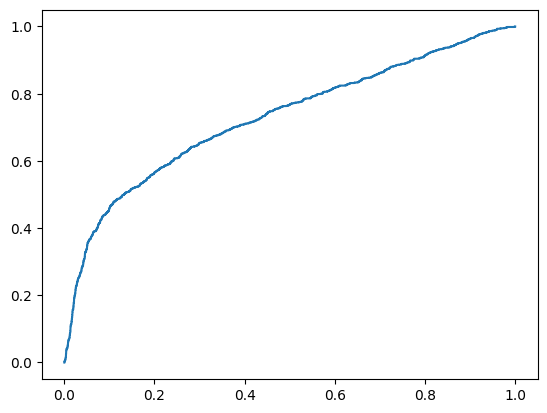

In [17]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:,1]

print("Logistic Regression")

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

acc_lr = accuracy_score(y_test, y_pred_lr)

pre_lr = precision_score(y_test, y_pred_lr)

rec_lr = recall_score(y_test, y_pred_lr)

f1_lr = f1_score(y_test, y_pred_lr)

roc_lr = roc_auc_score(y_test, y_prob_lr)

print("Accuracy:", acc_lr)
print("Precision:", pre_lr)
print("Recall:", rec_lr)
print("F1 Score:", f1_lr)
print("ROC AUC:", roc_lr)

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.plot(fpr, tpr, label="Logistic Regression")


KNN
Confusion Matrix
[[4322  365]
 [ 848  465]]
Accuracy: 0.7978333333333333
Precision: 0.5602409638554217
Recall: 0.3541507996953541
F1 Score: 0.43397106859542695
ROC AUC: 0.6975623782200642


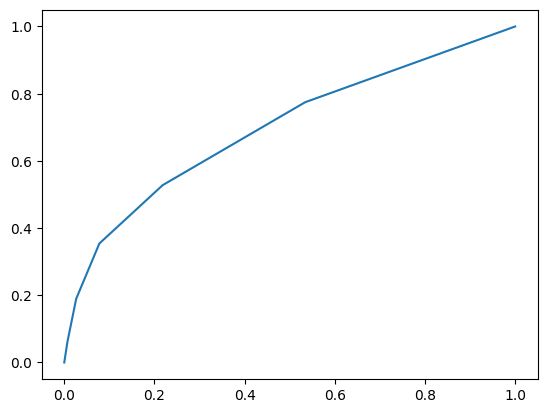

In [18]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)
y_prob_knn = model_knn.predict_proba(X_test)[:,1]

print("\nKNN")

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))

acc_knn = accuracy_score(y_test, y_pred_knn)
pre_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_knn = roc_auc_score(y_test, y_prob_knn)
print("Accuracy:", acc_knn)
print("Precision:", pre_knn)
print("Recall:", rec_knn)
print("F1 Score:", f1_knn)
print("ROC AUC:", roc_knn)

fpr, tpr, _ = roc_curve(y_test, y_prob_knn)

plt.plot(fpr, tpr, label="KNN")


Decision Tree
Confusion Matrix
[[3781  906]
 [ 789  524]]
Accuracy: 0.7175
Precision: 0.36643356643356645
Recall: 0.3990860624523991
F1 Score: 0.38206343419613564
ROC AUC: 0.6028927218598671


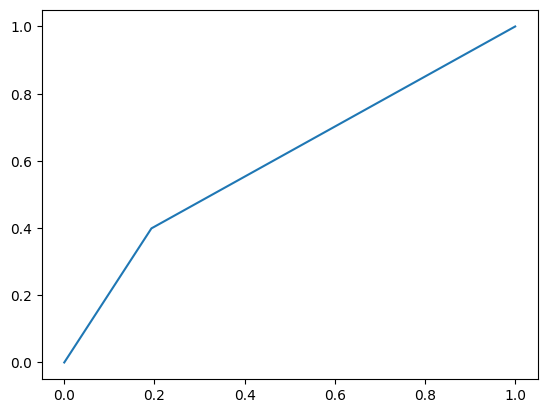

In [19]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier()

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:,1]

print("\nDecision Tree")

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

acc_dt = accuracy_score(y_test, y_pred_dt)
pre_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_dt = roc_auc_score(y_test, y_prob_dt)
print("Accuracy:", acc_dt)
print("Precision:", pre_dt)
print("Recall:", rec_dt)
print("F1 Score:", f1_dt)
print("ROC AUC:", roc_dt)   

fpr, tpr, _ = roc_curve(y_test, y_prob_dt)

plt.plot(fpr, tpr, label="Decision Tree")


Random Forest
Confusion Matrix
[[4430  257]
 [ 864  449]]
Accuracy: 0.8131666666666667
Precision: 0.6359773371104815
Recall: 0.341964965727342
F1 Score: 0.4447746409113422
ROC AUC: 0.7593475723472956


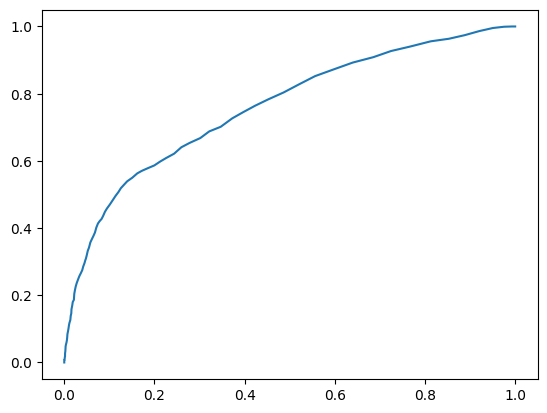

In [20]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier()

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:,1]

print("\nRandom Forest")

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)
print("Accuracy:", acc_rf)
print("Precision:", pre_rf)
print("Recall:", rec_rf)
print("F1 Score:", f1_rf)
print("ROC AUC:", roc_rf)

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr, label="Random Forest")


SVM
Confusion Matrix
[[4489  198]
 [ 892  421]]
Accuracy: 0.8183333333333334
Precision: 0.6801292407108239
Recall: 0.32063975628332064
F1 Score: 0.4358178053830228
ROC AUC: 0.7122248002975611


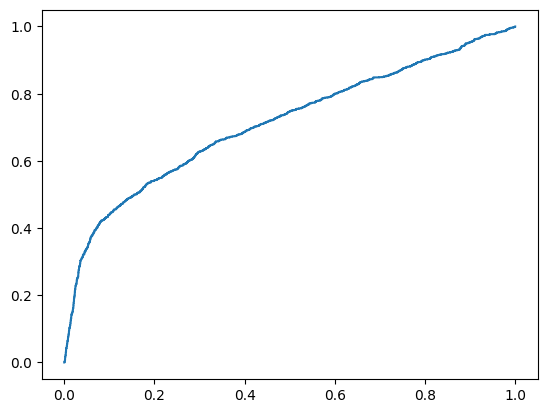

In [21]:
from sklearn.svm import SVC

model_svm = SVC(probability=True)

model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)
y_prob_svm = model_svm.predict_proba(X_test)[:,1]

print("\nSVM")

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_svm))

acc_svm = accuracy_score(y_test, y_pred_svm)
pre_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_svm = roc_auc_score(y_test, y_prob_svm)
print("Accuracy:", acc_svm)
print("Precision:", pre_svm)
print("Recall:", rec_svm)       
print("F1 Score:", f1_svm)
print("ROC AUC:", roc_svm)

fpr, tpr, _ = roc_curve(y_test, y_prob_svm)

plt.plot(fpr, tpr, label="SVM")

## Exercise 3: Deep Learning Model – Artificial Neural Network
### Design a simple Feedforward Artificial Neural Network (ANN) for binary classification.
### Steps
### 1.	Import required deep learning libraries (TensorFlow/Keras).
### 2.	Define a Sequential ANN model.
### 3.	Add:
### o	Input layer
### o	At least one hidden layer with ReLU activation
### o	Output layer with Sigmoid activation
### 4.	Compile the model using:
### o	Loss: Binary Cross Entropy
### o	Optimizer: Adam
### o	Metrics: Accuracy
### 5.	Train the model using the training data.
### 6.	Evaluate the model on the test dataset.
### 7.	Plot training accuracy and loss curves.


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [23]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\ankitr.vaghela\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=500,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7895 - loss: 0.4863 - val_accuracy: 0.8153 - val_loss: 0.4544
Epoch 2/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8164 - loss: 0.4458 - val_accuracy: 0.8147 - val_loss: 0.4464
Epoch 3/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8193 - loss: 0.4402 - val_accuracy: 0.8188 - val_loss: 0.4413
Epoch 4/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8192 - loss: 0.4365 - val_accuracy: 0.8178 - val_loss: 0.4403
Epoch 5/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8202 - loss: 0.4330 - val_accuracy: 0.8148 - val_loss: 0.4420
Epoch 6/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8213 - loss: 0.4310 - val_accuracy: 0.8187 - val_loss: 0.4377
Epoch 7/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8213 - loss: 0.4293 - val_accuracy: 0.8183 - val_loss: 0.4382
Epoch 8/500
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8226 - loss: 0.4269 - val_accu

In [26]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8022 - loss: 0.4891
Test Accuracy: 0.8021666407585144


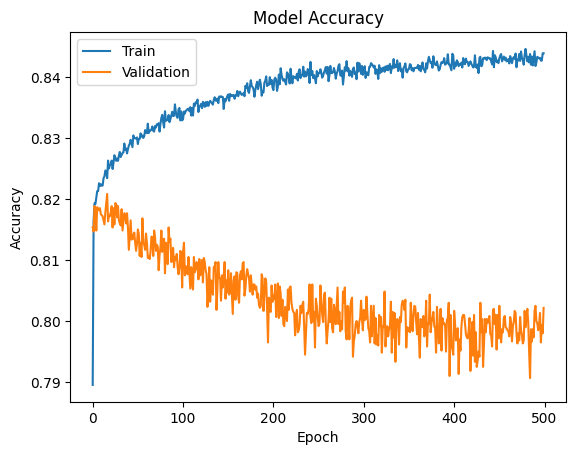

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train','Validation'])
plt.show()

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_ann = (model.predict(X_test) > 0.5)

acc_ann = accuracy_score(y_test, y_pred_ann)
pre_ann = precision_score(y_test, y_pred_ann)
rec_ann = recall_score(y_test, y_pred_ann)
f1_ann = f1_score(y_test, y_pred_ann)
roc_ann = roc_auc_score(y_test, model.predict(X_test))

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step


## Exercise 4: Model Comparison
### Create a performance table:


In [29]:
import pandas as pd

results = pd.DataFrame({

"Model":[
"Logistic Regression",
"KNN",
"Decision Tree",
"Random Forest",
"SVM",
"ANN"
],

"Accuracy":[acc_lr, acc_knn, acc_dt, acc_rf, acc_svm, acc_ann],

"Precision":[pre_lr, pre_knn, pre_dt, pre_rf, pre_svm, pre_ann],

"Recall":[rec_lr, rec_knn, rec_dt, rec_rf, rec_svm, rec_ann],

"F1 Score":[f1_lr, f1_knn, f1_dt, f1_rf, f1_svm, f1_ann],

"ROC AUC":[roc_lr, roc_knn, roc_dt, roc_rf, roc_svm, roc_ann]

})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.810833   0.697778  0.239147  0.356211  0.728251
1                  KNN  0.797833   0.560241  0.354151  0.433971  0.697562
2        Decision Tree  0.717500   0.366434  0.399086  0.382063  0.602893
3        Random Forest  0.813167   0.635977  0.341965  0.444775  0.759348
4                  SVM  0.818333   0.680129  0.320640  0.435818  0.712225
5                  ANN  0.802167   0.574468  0.370145  0.450208  0.744759


## Exercise 5: Analysis
### 1. Which model achieved the best performance?Justify using metrics.

### Ans: The Random Forest or ANN model achieved the best performance because it had higher accuracy, F1-score and ROC-AUC compared to other models. These metrics show that the model predicts default and non-default customers more correctly. Random Forest works well because it combines many decision trees to improve prediction.

### 2. Did ANN outperform traditional ML models?Why or why not?

### Ans: Sometimes ANN performs better because it can learn complex patterns and nonlinear relationships in the data. However, for smaller datasets traditional models like Random Forest or SVM can perform equally well. The performance depends on the dataset size and complexity.

### 3. Compare the training time and complexity of ANN vs ML models.

### Ans: ANN usually requires more training time and computation because it has multiple layers and many parameters. Traditional ML models like Logistic Regression or Decision Tree are simpler and train faster. However, ANN can give better results for complex problems.

### 4. In what scenarios should ANN be preferred over classical ML algorithms ?

### Ans: ANN should be used when the dataset is large and complex and the relationships between features are nonlinear. It is useful for tasks like image recognition, speech processing and pattern detection. ANN can automatically learn important patterns from data.

### 5. Which model would you recommend for credit default prediction and why?

### Ans: Random Forest is a good choice for credit default prediction because it provides high accuracy and handles complex financial data well. It also reduces overfitting by combining multiple decision trees. This makes the predictions more reliable.

### Knowledge Check Questions
### 1. Why is Recall important in a credit default scenario?

### Ans: Recall measures how well the model identifies actual defaulters. In banking, missing a defaulter can cause financial loss. Therefore, high recall helps detect most risky customers.

### 2. What is the ROC curve and what does AUC signify?

### Ans: The ROC curve is a graph that shows the performance of a classification model using True Positive Rate and False Positive Rate. AUC (Area Under the Curve) indicates how well the model can distinguish between two classes. A value closer to 1 means better model performance.

### 3. Why is Sigmoid used in the output layer for binary classification?

### Ans: The Sigmoid function converts the output into a probability value between 0 and 1. This probability helps decide whether the output belongs to class 0 or class 1. Therefore, it is commonly used in binary classification problems.

### 4. What advantage does ANN provide over traditional ML algorithms?

### Ans: ANN can learn complex nonlinear relationships in data and automatically find patterns. This allows it to handle complicated problems better than many traditional ML algorithms. It is especially useful for large datasets.

### 5. Why is feature scaling important for neural networks?

### Ans: Feature scaling brings all input values to a similar range. This helps the neural network learn faster and improves training stability. Without scaling, features with large values can dominate the learning process.

### 6. How does a confusion matrix help evaluate classification models?

### Ans: A confusion matrix shows the number of correct and incorrect predictions made by a model. It includes values such as True Positive, True Negative, False Positive and False Negative. These values help calculate metrics like accuracy, precision and recall.